# Benchmark 1D 

In [18]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import tensorflow as tf
from generalization import Neural_network, MultiFidelity

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

# Creation of the model

In [19]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

HPO = False

#Benchmark1
highfid = lambda x: (6.*x/5-2.)**2*np.sin(12.*x/5-4.)
lowfid  = lambda x: 0.5*highfid(x) + 10*(x/5-0.5) + 5.
Nhf = 5
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

NepoLF = 1000
NepoHF = 500

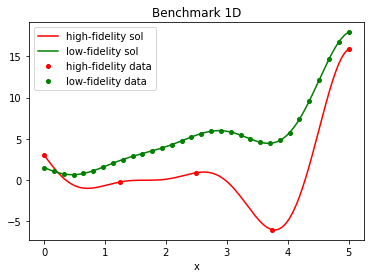

In [20]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [21]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
modelLF.performance(x_test,highfid(x_test))

Test MSE: 32.5572143038741
R^2: -0.6311736035457454


(32.5572143038741, -0.6311736035457454)

## High fidelity model

In [22]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
modelHF.performance(x_test,highfid(x_test))

Test MSE: 19.782447250972815
R^2: 0.008864656903917023


(19.782447250972815, 0.008864656903917023)

## 2 Step model

In [23]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
final_model.model_list[1].performance(input_HF,highfid(x_test))

Test MSE: 0.7125839990678616
R^2: 0.964298290426824


(0.7125839990678616, 0.964298290426824)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

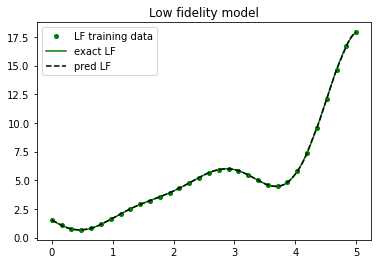

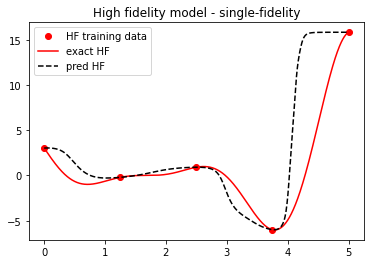

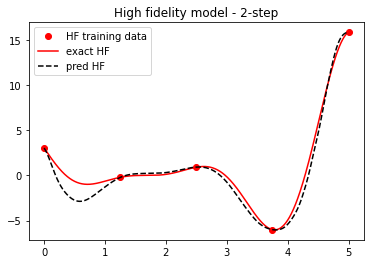

In [24]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using tinyDA

In [35]:
dim=5
real_x = np.random.rand(dim)*5
observed_output = highfid(real_x)
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)

In [36]:

# class MultivariateUniform:
#     def __init__(self, low=0, high=1):
#         self.low = np.array(low)
#         self.high = np.array(high)

#     def rvs(self, size=1, random_state=None):
#         rng = np.random.default_rng(random_state)
#         samples = rng.uniform(low=self.low, high=self.high, size=(size, len(self.low)))
#         return samples

#     def logpdf(self, x):
#         if x.shape[1] != len(self.low):
#             raise ValueError("Input dimension does not match the distribution dimension.")

#         logpdf_values = np.sum(np.log(1 / (self.high - self.low)))

#         mask = np.all((x >= self.low) & (x <= self.high), axis=1) # metterlo in condizione errore?
#         logpdf_values = np.where(mask, logpdf_values, -np.inf)

#         return logpdf_values

# # Esempio di utilizzo
# multivariate_uniform = MultivariateUniform(low=[0, 0], high=[1, 2])
# samples = multivariate_uniform.rvs(size=1000)
# logpdf_values = multivariate_uniform.logpdf(samples)
# # Esempio di utilizzo
# multivariate_uniform = MultivariateUniform(low=[0, 0], high=[1, 2])
# samples = multivariate_uniform.rvs(size=1000)
# logpdf_values = multivariate_uniform.logpdf(samples)



### Low Fidelity

In [37]:
my_prior =multivariate_normal(mean_prior, cov_prior) # modo per settare uniforme? # MultivariateUniform(np.zeros(dim), np.ones(dim))#

sigma=1
cov_likelihood = 1**2*np.eye(real_x.shape[0])
my_loglike = tda.GaussianLogLike(highfid(real_x)+np.random.normal(scale=sigma, size=dim), cov_likelihood)

my_posterior = tda.Posterior(my_prior, my_loglike, modelLF.prediction)

In [38]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 0.35: 100%|██████████| 5000/5000 [07:20<00:00, 11.34it/s]


Sampling chain 2/2


Running chain, α = 0.15:  31%|███       | 1548/5000 [02:42<04:59, 11.53it/s]

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.560  0.314   0.105    1.210      0.025    0.018     244.0     111.0   
x1  1.475  1.269   0.183    3.835      0.853    0.734       4.0      17.0   
x2  1.757  0.480   0.948    2.484      0.072    0.064     111.0      45.0   
x3  3.653  0.113   3.444    3.857      0.004    0.003     835.0    1256.0   
x4  1.078  0.487   0.201    2.034      0.048    0.034     105.0     245.0   

    r_hat  
x0   1.01  
x1   1.58  
x2   1.03  
x3   1.00  
x4   1.00  
[0.27746856 0.23505282 0.00809352 0.46958303 0.10676478]


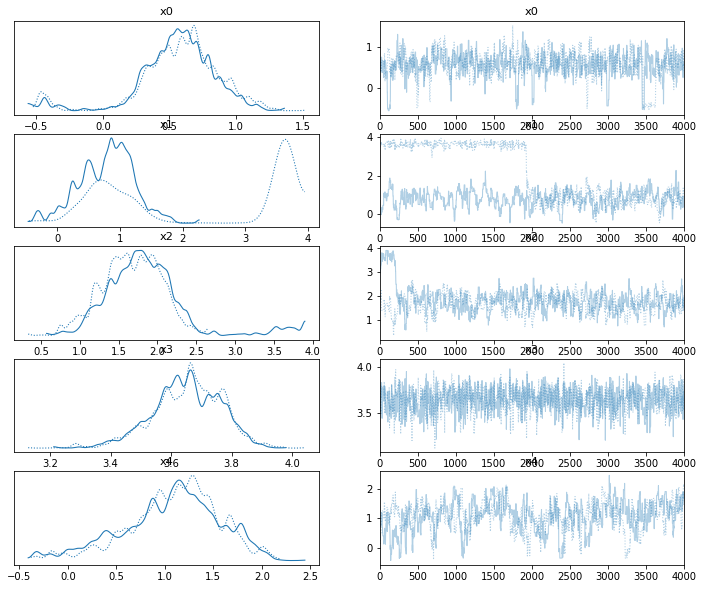

In [ ]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


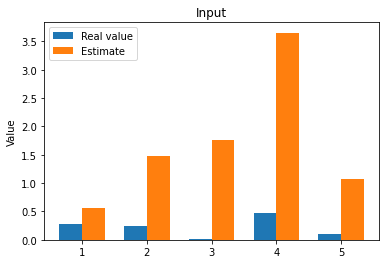

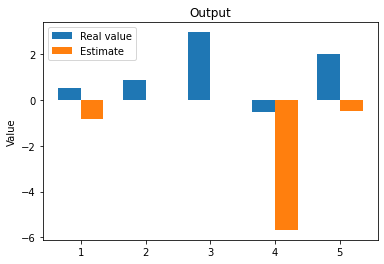

In [ ]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()



## High fidelity


In [14]:
my_posterior = tda.Posterior(my_prior, my_loglike, modelHF.prediction)

In [15]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = False
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 0.18: 100%|██████████| 500/500 [00:41<00:00, 12.06it/s]


Sampling chain 2/2


Running chain, α = 0.14: 100%|██████████| 500/500 [00:34<00:00, 14.35it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.726  1.467   0.212    3.354      1.026    0.865       3.0      47.0   
x1  3.354  0.238   2.821    3.672      0.073    0.053      11.0      24.0   
x2  1.744  1.487   0.179    3.467      1.038    0.874       3.0      12.0   
x3  1.683  1.424   0.228    3.320      0.995    0.838       3.0      28.0   
x4  1.795  1.481   0.105    3.566      1.034    0.871       2.0      12.0   

    r_hat  
x0   1.99  
x1   1.13  
x2   2.03  
x3   1.96  
x4   2.70  
[0.77132064 0.02075195 0.63364823 0.74880388 0.49850701]


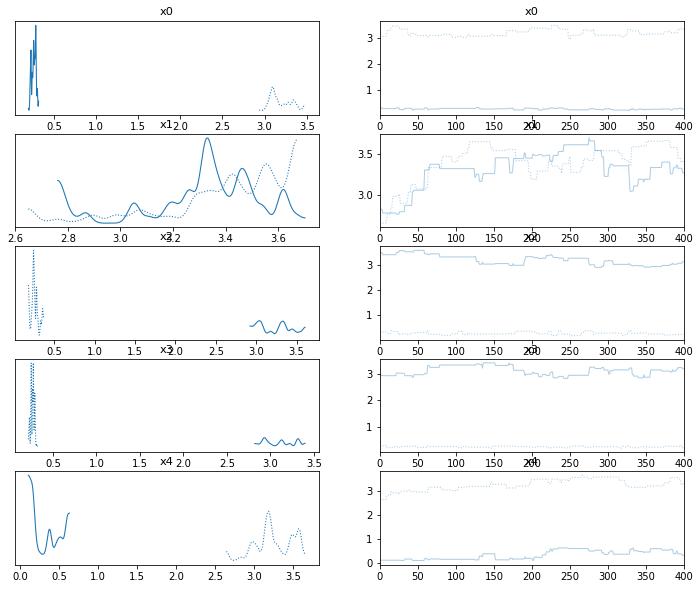

In [16]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


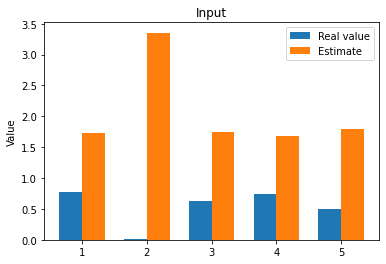

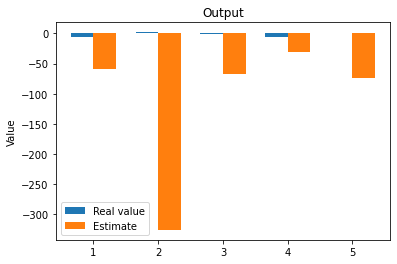

In [17]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


# MF

In [ ]:
my_posterior = tda.Posterior(my_prior, my_loglike, modelHF.prediction)

In [ ]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

In [ ]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


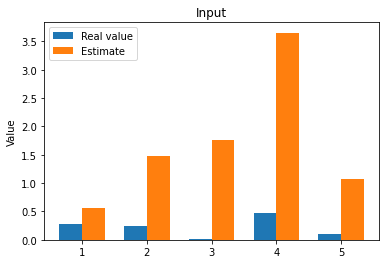

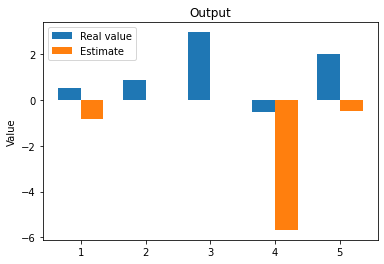

In [ ]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()

